In [201]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV,StratifiedKFold
from sklearn.linear_model import LogisticRegression

In [202]:
data = pd.read_csv("student_placement_data (1).csv")


In [203]:
data

,CGPA,Class_X_Marks,Class_XII_Marks,Annual_Income_LPA,Placed,Salary_Package_LPA
0,6.87,78.42,79.01,4.61,1,4.40
1,9.75,93.76,67.69,5.68,0,NaN
2,8.66,84.50,79.09,1.67,1,4.37
3,7.99,69.23,85.30,0.89,1,3.60
4,5.78,66.02,81.85,2.35,0,NaN
...,...,...,...,...,...,...
495,6.77,69.69,66.15,5.93,1,4.87
496,7.92,70.11,97.89,0.61,1,4.18
497,5.39,85.44,64.73,1.01,1,3.09
498,9.87,81.82,80.91,1.59,1,4.67


In [204]:
df_cls = data.drop(columns=['Salary_Package_LPA'],axis=1)
df_reg = data.drop(columns=['Placed'],axis=1)

In [205]:
df_reg=df_reg.dropna()

In [206]:
dt = pd.DataFrame(data['Placed'].value_counts())


<Axes: xlabel='Placed', ylabel='count'>

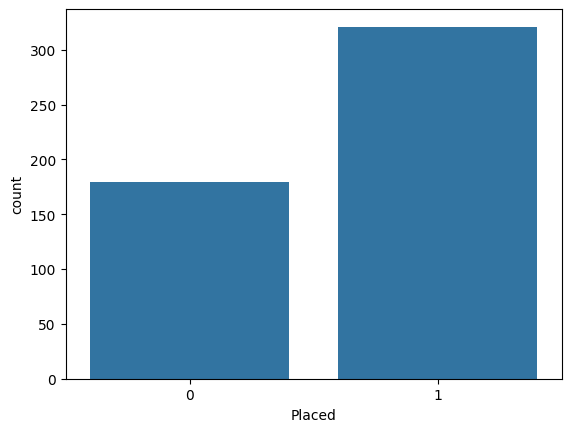

In [207]:
sns.barplot(data=dt,x=dt.index,y=dt['count'])

In [208]:
X_cls = df_cls.drop(['Placed'],axis=1)
y_cls = df_cls['Placed']

In [209]:
kf = KFold(n_splits=5,shuffle=True,random_state=0)
kf=StratifiedKFold(n_splits=5,shuffle=True,random_state=0)
k=0
train=[]
test=[]
test_a=[]
for train_index,test_index in kf.split(X_cls,y_cls):
    X_train,X_test,y_train,y_test = X_cls.iloc[train_index],X_cls.iloc[test_index],y_cls.iloc[train_index],y_cls.iloc[test_index]
    sm = SMOTE(random_state=0)
    st = StandardScaler()
    X_train = st.fit_transform(X_train)
    X_test = st.transform(X_test)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    model = LogisticRegression(random_state=0)
    model.fit(X_res,y_res)
    train_acc = model.score(X_res,y_res)
    test_acc = model.score(X_test,y_test)
    train.append([X_train,y_train])
    test.append([X_test,y_test])
    test_a.append(test_acc)
    print(f"Fold k={k+1}")
    k+=1
    print(f"Train_acc:{train_acc:.2f}")
    print(f"Test_acc:{test_acc:.2f}")

Fold k=1
Train_acc:0.59
Test_acc:0.63
Fold k=2
Train_acc:0.56
Test_acc:0.48
Fold k=3
Train_acc:0.59
Test_acc:0.47
Fold k=4
Train_acc:0.63
Test_acc:0.50
Fold k=5
Train_acc:0.60
Test_acc:0.59


In [210]:
X_train,y_train =train[np.argmax(test_a)] 

In [211]:
X_test,y_test =test[np.argmax(test_a)] 

In [212]:
np.argmax(test_a)

np.int64(0)

In [213]:
params = {'C':[0.01,0.1,1,2,3,4,5],
         'solver':['lbfgs','liblinear','newton-cg']}
model = LogisticRegression(random_state=0)
gd = GridSearchCV(model,params,scoring='neg_mean_squared_error',cv=kf,n_jobs=-1)

In [214]:
gd.fit(X_train,y_train)


,estimator,LogisticRegre...andom_state=0)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [215]:
gd.best_params_

{'C': 0.1, 'solver': 'lbfgs'}

In [216]:
model = LogisticRegression(C=0.1,solver='lbfgs')
model.fit(X_train,y_train)
train_acc = model.score(X_train,y_train)
test_acc = model.score(X_test,y_test)
print(f"Train_acc:{train_acc:.2f}")
print(f"Test_acc:{test_acc:.2f}")

Train_acc:0.65
Test_acc:0.65


### Continue the Regression part